# Libraries
To begin with I have imported all the libraries needed for running this project file :

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Dataset Construction
Importing the [main data file](https://www.kaggle.com/datasets/moazeldsokyx/imdb-top-10000-movies-dataset) which contains the 10,000 top rated IMDB movies and is going to be cleaned and merged with other datasets to contain all the necessary information before implementing methods.


In [2]:
top_10k_imdb_data = pd.read_csv('datasets/top_10k_movies_IMDB.csv')

# Cleaning the Runtime column to remove 'min' and convert to float
top_10k_imdb_data['Runtime'] = (
    top_10k_imdb_data['Runtime']
    .str.replace(" min", "")
    .str.strip()
    .astype(float)
)

# Dropping unnecessary columns and standardizing names
top_10k_imdb_data.drop(columns=['ID', 'Directors', 'Metascore', 'Plot', 'Stars', 'Gross', 'Votes'], axis=1, inplace=True)
top_10k_imdb_data.rename(columns={'Movie Name': 'movie_name'}, inplace=True)
top_10k_imdb_data.columns = top_10k_imdb_data.columns.str.lower()

top_10k_imdb_data.head()

,movie_name,rating,runtime,genre,link
0,The Shawshank Redemption,9.3,142.0,Drama,https://www.imdb.com/title/tt0111161/
1,The Godfather,9.2,175.0,"Crime, Drama",https://www.imdb.com/title/tt0068646/
2,Ramayana: The Legend of Prince Rama,9.2,135.0,"Animation, Action, Adventure",https://www.imdb.com/title/tt0259534/
3,The Chaos Class,9.2,87.0,"Comedy, Drama",https://www.imdb.com/title/tt0252487/
4,Daman,9.1,121.0,"Adventure, Drama",https://www.imdb.com/title/tt17592606/


Importing the [first supplementary dataset](https://www.kaggle.com/datasets/gorochu/complete-imdb-movies-dataset/data) from which I will obtain the countries of first release `countries_released` , languages in which the movie was released `languages_released` , movies year of release `year` , movies age certificate `certificate` and the number of actors `Nact` columns."


In [3]:
complete_imdb_data = pd.read_csv('datasets/complete_IMDB_movies_dataset.csv')

# Keeping only the count of actors/directors instead of lists
complete_imdb_data['number_of_actors'] = complete_imdb_data['actors'].apply(
    lambda x: len(ast.literal_eval(x))
)

complete_imdb_data.dropna(subset=['directors'], inplace=True)
complete_imdb_data['number_of_directors'] = complete_imdb_data['directors'].apply(
    lambda x: len(ast.literal_eval(x))
)

complete_imdb_data.rename(columns={
    "rating": "certificate", 
    "genre": "genre_completeIMDB",
    'countries': 'countries_published', 
    'languages': 'languages_published'
}, inplace=True)

complete_imdb_data.drop(columns=['votes', 'metascore', 'img_url', 'actors', 'tagline',
                                  'description', 'runtime', 'title', 'users_rating', 'directors'], axis=1, inplace=True)

complete_imdb_data.head()

,certificate,year,countries_published,languages_published,genre_completeIMDB,imdb_url,number_of_actors,number_of_directors
0,PG-13,2019.0,['USA'],['English'],"['Comedy', 'Romance']",https://www.imdb.com/title/tt7139936/,15,1
1,18,2020.0,['USA'],['English'],"['Horror', 'Thriller']",https://www.imdb.com/title/tt12384178/,15,3
2,PG-13,1986.0,['USA'],"['English', 'German']",['Comedy'],https://www.imdb.com/title/tt0091042/,15,1
3,R,1991.0,['USA'],['English'],"['Crime', 'Thriller']",https://www.imdb.com/title/tt0101540/,15,1
4,PG-13,2004.0,"['USA', 'Canada']","['English', 'German', 'Vietnamese', 'Swahili']",['Comedy'],https://www.imdb.com/title/tt0377092/,15,1


Merging the `top_10k_imdb_data` datafrme with `complete_imdb_data` dataframe with an inner merge to obtain a new dataframe of movies which are in both of the dataframes using the imdb link of movies as the merge key. Using this merge __6612__ rows of data are preserved to be used for the next steps.


In [4]:
top_10k_and_complete_imdb = top_10k_imdb_data.merge(
    complete_imdb_data, 
    how="inner", 
    left_on="link", 
    right_on="imdb_url"
)

top_10k_and_complete_imdb['countries_published'] = top_10k_and_complete_imdb['countries_published'].apply(
    lambda x: len(ast.literal_eval(x))
)

top_10k_and_complete_imdb['languages_published'] = top_10k_and_complete_imdb['languages_published'].apply(
    lambda x: len(ast.literal_eval(x))
)

top_10k_and_complete_imdb.drop(columns=['link', 'imdb_url'], axis=1, inplace=True)

top_10k_and_complete_imdb.head()

,movie_name,rating,runtime,genre,certificate,year,countries_published,languages_published,genre_completeIMDB,number_of_actors,number_of_directors
0,The Shawshank Redemption,9.3,142.0,Drama,R,1994.0,1,1,['Drama'],15,1
1,The Godfather,9.2,175.0,"Crime, Drama",R,1972.0,1,3,"['Crime', 'Drama']",15,1
2,The Dark Knight,9.0,152.0,"Action, Crime, Drama",PG-13,2008.0,2,2,"['Action', 'Crime', 'Drama', 'Thriller']",15,1
3,Schindler's List,9.0,195.0,"Biography, Drama, History",R,1993.0,1,5,"['Biography', 'Drama', 'History']",15,1
4,12 Angry Men,9.0,96.0,"Crime, Drama",Approved,1957.0,1,1,"['Crime', 'Drama']",12,1


Unifying genre columns by selecting all the unique genres available for each movie in both the columns `genre` and `genre_completeIMDB`.

In [5]:
top_10k_and_complete_imdb['genre_completeIMDB'] = top_10k_and_complete_imdb['genre_completeIMDB'].apply(
    lambda x: ast.literal_eval(x)
)

top_10k_and_complete_imdb['genre'] = top_10k_and_complete_imdb['genre'].apply(
    lambda x: [i.strip() for i in x.split(',')]
)

top_10k_and_complete_imdb['genre'] = (
    top_10k_and_complete_imdb['genre_completeIMDB'] + top_10k_and_complete_imdb['genre']
).apply(lambda x: list(set(x)))

top_10k_and_complete_imdb.drop(columns=['genre_completeIMDB'], axis=1, inplace=True)

top_10k_and_complete_imdb.head()

,movie_name,rating,runtime,genre,certificate,year,countries_published,languages_published,number_of_actors,number_of_directors
0,The Shawshank Redemption,9.3,142.0,[Drama],R,1994.0,1,1,15,1
1,The Godfather,9.2,175.0,"[Drama, Crime]",R,1972.0,1,3,15,1
2,The Dark Knight,9.0,152.0,"[Drama, Action, Crime, Thriller]",PG-13,2008.0,2,2,15,1
3,Schindler's List,9.0,195.0,"[Drama, History, Biography]",R,1993.0,1,5,15,1
4,12 Angry Men,9.0,96.0,"[Drama, Crime]",Approved,1957.0,1,1,12,1


Importing the [second supplementary dataset](https://www.kaggle.com/datasets/michaelmatta0/movies-ultimate-metrics-features-and-metadata?select=Top+Movies+%28Cleaned+Data%29.csv) from which I will obtain the finantial data for the movies in the dataset beside some explanatory variables. After the merge __2862__ observations remain to continue with.


In [6]:
top_movies_worldwide = pd.read_csv('datasets/6.5k_top_movies_worldwide.csv')

# Selecting specific columns of the dataset as there are many columns
top_movies_worldwide = top_movies_worldwide[['Movie Name', 'Release Date', 'Production Budget (USD)', 'Domestic Box Office (USD)',
                                             'International Box Office (USD)', 'Infl. Adj. Dom. BO (USD)', 'Franchise',
                                             'Source','Production Method', 'Creative Type']]

# Dropping rows with missing financial values
top_movies_worldwide.dropna(subset=['Domestic Box Office (USD)', 'International Box Office (USD)', 'Infl. Adj. Dom. BO (USD)'], inplace=True)

# Adjusting International Box Office for inflation
top_movies_worldwide['IBO'] = ((
    top_movies_worldwide['Infl. Adj. Dom. BO (USD)'] / top_movies_worldwide['Domestic Box Office (USD)']) 
    * top_movies_worldwide['International Box Office (USD)'])

# Changing the dates into only year values
top_movies_worldwide['Release Date'] = pd.to_datetime(top_movies_worldwide['Release Date']).dt.year

top_movies_worldwide.rename(columns={'Domestic Box Office (USD)': 'DBO',
                                     'Production Budget (USD)': 'production_budget',
                                     'Release Date': 'year_ww'}, inplace=True)

top_movies_worldwide.drop(columns=['International Box Office (USD)', 'Infl. Adj. Dom. BO (USD)'], axis=1, inplace=True)

top_movies_worldwide.head()


,Movie Name,year_ww,production_budget,DBO,Franchise,Source,Production Method,Creative Type,IBO
0,Star Wars Ep. VII: The Force Awakens,2015.0,533200000,936662225.0,Star Wars,Original Screenplay,"Animation,Live Action",Science Fiction,1.423873e+09
1,Avatar: The Way of Water,2022.0,460000000,684075767.0,Avatar,Original Screenplay,"Animation,Live Action",Science Fiction,1.654221e+09
2,Indiana Jones and the Dial of Destiny,2023.0,402300000,174480468.0,Indiana Jones,Original Screenplay,Live Action,Historical Fiction,2.094826e+08
3,Avengers: Endgame,2019.0,400000000,858373000.0,Marvel Cinematic UniverseAvengers,Based on Comic/Graphic Novel,"Animation,Live Action",Super Hero,2.224104e+09
5,Pirates of the Caribbean: On Stranger Tides,2011.0,379000000,241071802.0,Pirates of the Caribbean,Based on Theme Park Ride,Live Action,Historical Fiction,1.093826e+09


Merging the `top_10k_and_complete_imdb` datafrme with `top_movies_worldwide` dataframe with an inner merge to obtain a new dataframe of movies which are in both of the dataframes using the movie names and movies year of release as the merge key. Using this merge __2862__ rows of data are preserved to be used for the next steps.

In [7]:
movies_df = top_10k_and_complete_imdb.merge(
    top_movies_worldwide, 
    how="inner", 
    left_on=["movie_name", "year"], 
    right_on=["Movie Name", "year_ww"]
)

# Changing values into million dolars.
movies_df['DBO'] = movies_df['DBO'] / 1000000
movies_df['IBO'] = movies_df['IBO'] / 1000000
movies_df['production_budget'] = movies_df['production_budget'] / 1000000

# Binarizing the value for the Franchise column not to have "na" values as they should be removed in the next step
movies_df['has_franchise'] = np.where(movies_df['Franchise'].notna(), 'Yes', 'No')
movies_df.drop(columns=['movie_name', 'Movie Name', "year_ww", 'Franchise', 'Creative Type'], axis=1, inplace=True)

movies_df.rename(columns={'Source': 'source', 'Production Method': 'production_method'}, inplace=True)

movies_df.head()

,rating,runtime,genre,certificate,year,countries_published,languages_published,number_of_actors,number_of_directors,production_budget,DBO,source,production_method,IBO,has_franchise
0,9.3,142.0,[Drama],R,1994.0,1,1,15,1,25.0,28.313053,Based on Fiction Book/Short Story,Live Action,1.212427,No
1,9.0,152.0,"[Drama, Action, Crime, Thriller]",PG-13,2008.0,2,2,15,1,185.0,536.625724,Based on Comic/Graphic Novel,Live Action,707.404842,Yes
2,8.9,154.0,"[Drama, Crime]",R,1994.0,1,3,15,1,8.0,107.928762,Original Screenplay,Live Action,270.267906,No
3,8.8,148.0,"[Adventure, Action, Thriller, Sci-Fi]",PG-13,2010.0,2,3,15,1,160.0,293.662683,Original Screenplay,"Animation,Live Action",726.020713,No
4,8.8,139.0,[Drama],R,1999.0,2,1,15,1,65.0,37.030102,Based on Fiction Book/Short Story,Live Action,135.258900,No


Checking the number of rows containing any NA values we can observe that they are very few and as there are only a few we can remove them from the dataset. As a result 2855 rows of data will remain to work with.

In [8]:
print(movies_df.isna().sum())
movies_df.dropna(axis=0, inplace=True)

rating                 0
runtime                0
genre                  0
certificate            1
year                   0
countries_published    0
languages_published    0
number_of_actors       0
number_of_directors    0
production_budget      0
DBO                    0
source                 5
production_method      2
IBO                    0
has_franchise          0
dtype: int64


Now that we have the dataset ready to apply probability based approaches the categorical data has to be controled not to have super rare outcomes (in this case all those outcomes will be considered as a unique unified category) and numerical data has get categorized. Here I have started with categorizing the descrete numeric values.

In [9]:
movies_df['rating_category'] = pd.cut(
    movies_df['rating'], 
    bins=[0, 5, 6, 7, 8, 10], 
    labels=['Poor', 'Below Average', 'Average', 'Above Average', 'Good']
)

movies_df['runtime_category'] = pd.cut(
    movies_df['runtime'], 
    bins=[0, 90, 150, 1000], 
    labels=['Short', 'Average', 'Long']
)

movies_df['year'] = pd.cut(
    movies_df['year'],
    bins=[0, 1989, 1999, 2004, 2010, 2015, 2025],
    labels=['Before 1990s', '1990s', '2000 to 2005', '2005 to 2010', '2010 to 2015', '2015 to 2020']
)

movies_df['number_of_directors'] = pd.cut(
    movies_df['number_of_directors'],
    bins=[0, 1, 2, 3],
    labels=['1', '2', '3']
)

movies_df['number_of_actors'] = pd.cut(
    movies_df['number_of_actors'],
    bins=[0, 5, 10, 14, 100],
    labels=['1 to 5', '5 to 10', '10 to 15', '15 or more']
)

movies_df['countries_published'] = pd.cut(
    movies_df['countries_published'],
    bins=[0, 1, 2, 3, 4, 5, 20],
    labels=['One', 'Two', 'Three', 'Four', 'Five', 'More than 5']
)
movies_df['languages_published'] = pd.cut(
    movies_df['languages_published'],
    bins=[0, 1, 2, 3, 4, 5, 20],
    labels=['One', 'Two', 'Three', 'Four', 'Five', 'More than 5']
)

In this step the continuous numeric values are categorized.

In [10]:
movies_df['DBO_category'] = pd.cut(
    movies_df['DBO'],
    bins=[0, 10, 25, 50, 75, 100, 125, 150, 200, 300, 900],
    labels=["Below 10 Million($)", "10 to 25 Million($)", "25 to 50 Million($)",
            "50 to 75 Million($)", "75 to 100 Million($)", "100 to 125 Million($)",
            "125 to 150 Million($)", "150 to 200 Million($)", "200 to 300 Million($)",
            "Above 300 Million($)"]
)

movies_df['IBO_category'] = pd.cut(
    movies_df['IBO'],
    bins=[0, 5, 10, 25, 50, 100, 150, 200, 300, 500, 3500],
    labels=["Below 5 Million($)", "5 to 10 Million($)", "10 to 25 Million($)",
            "25 to 50 Million($)", "50 to 100 Million($)", "100 to 150 Million($)",
            "150 to 200 Million($)", "200 to 300 Million($)", "300 to 500 Million($)",
            "Above 500 Million($)"]
)

movies_df['production_budget_category'] = pd.cut(
    movies_df['production_budget'],
    bins=[0, 5, 10, 25, 50, 75, 100, 150, 200, 401],
    labels=["Below 5 Million($)", "5 to 10 Million($)", "10 to 25 Million($)",
            "25 to 50 Million($)", "50 to 75 Million($)", "75 to 100 Million($)",
            "100 to 150 Million($)", "150 to 200 Million($)", "Above 200 Million($)"]
)

A specific function is defined to unify all the low frequency categories of the categorical data.

In [11]:
def low_freq_unifier(df, column_name, threshold,cat_name="others"):
    df[column_name].apply(lambda x: str.strip(x))
    counts = df[column_name].value_counts()
    rows_to_change = counts[counts < threshold].index
    df.loc[df[column_name].isin(rows_to_change), column_name] = cat_name

low_freq_unifier(movies_df, 'source', 10)
low_freq_unifier(movies_df, 'certificate', 10)
low_freq_unifier(movies_df, 'production_method', 11)


Finally creating binary categories for all the genres available in the dataset for each movie to eliminate the list type values which cannot be interpreted by pgmpy.

In [12]:
# Getting all the unique genres available
all_genres = sorted({g for genres in movies_df['genre'] for g in genres})

for g in all_genres:
    movies_df[str.lower(g)] = movies_df['genre'].apply(lambda x: 'Yes' if g in x else 'No')

# Data Visualization
To begin the visualization I have tried to demonstrate the quantity of the each movie genres in a way that if a movie has multiple genres it is counted once for each genre to see the real differences among their total number.

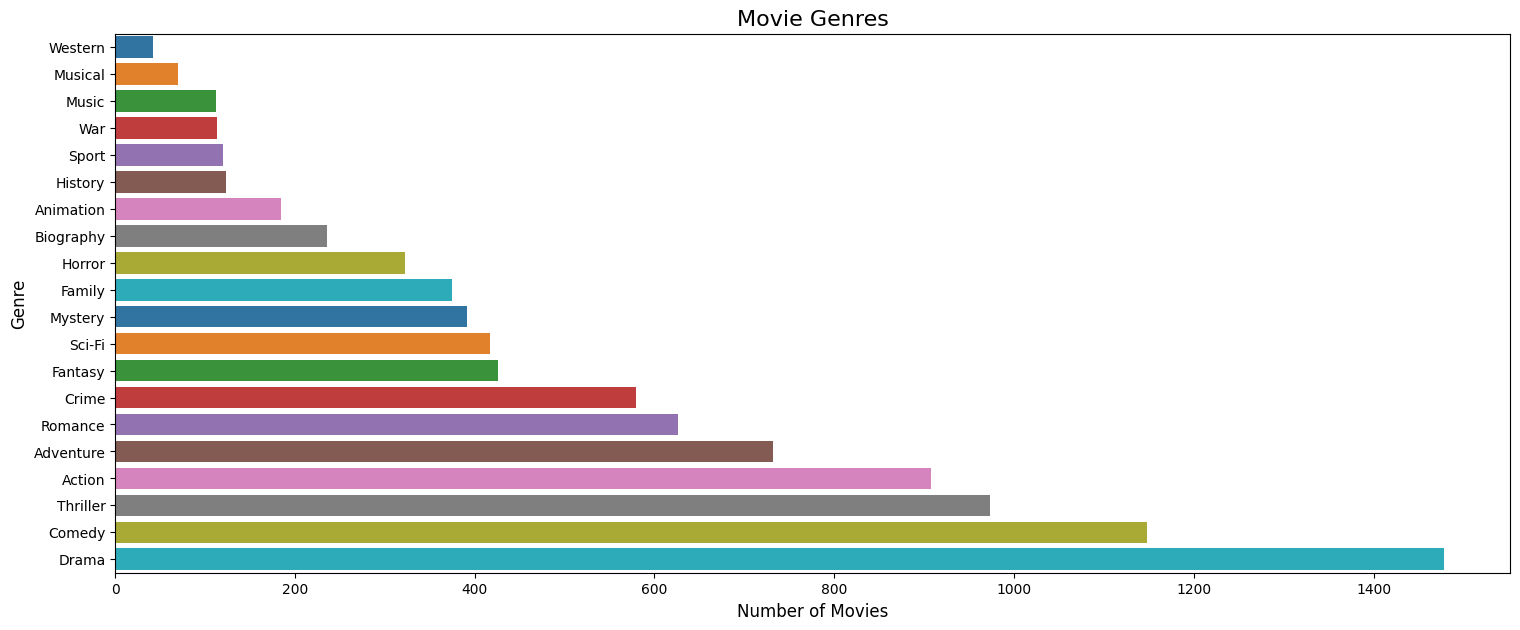

In [ ]:
genre_exploded_df = movies_df.explode('genre')
genre_counts = genre_exploded_df['genre'].value_counts().sort_values()

plt.figure(figsize=(18, 7))
sns.barplot(
    x=genre_counts.values, 
    y=genre_counts.index, 
    palette=sns.color_palette()
)

plt.title('Movie Genres', fontsize=16)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

A heatmap plot is created to observe the frequency of IMDB rating for movies including a genre. We can observe that movies having the `Drama` genre tend to have a better rating but at the same time this relation is kida the opposite for some other genres as they are right screwed.

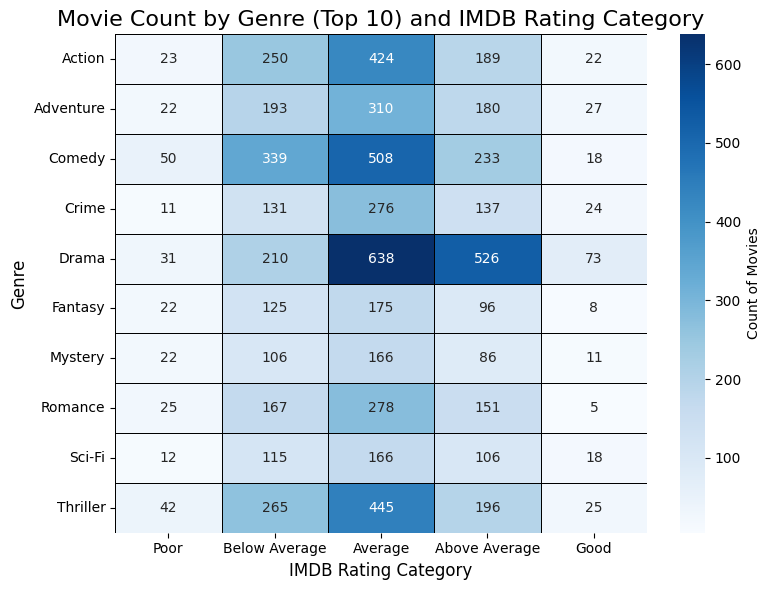

In [14]:
top_genres = genre_exploded_df['genre'].value_counts().nlargest(10).index.tolist()
filtered_df = genre_exploded_df[genre_exploded_df['genre'].isin(top_genres)]

contingency_table_genre_rating = pd.crosstab(
    filtered_df['genre'], 
    filtered_df['rating_category']
)

rating_order = ['Poor', 'Below Average', 'Average', 'Above Average', 'Good']
contingency_table_genre_rating = contingency_table_genre_rating.reindex(columns=rating_order)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    contingency_table_genre_rating,
    annot=True,
    fmt='d',
    cmap='Blues',
    linecolor='Black',
    linewidths=.5,
    cbar_kws={'label': 'Count of Movies'},
    cbar=True
)
plt.title('Movie Count by Genre (Top 10) and IMDB Rating Category', fontsize=16)
plt.ylabel('Genre', fontsize=12)
plt.xlabel('IMDB Rating Category', fontsize=12)

for _, spine in ax.spines.items():
    spine.set_color('black')
    spine.set_linewidth(1)

plt.yticks(rotation=0)
plt.tight_layout()

Movies rating category distribution is close to normal distribution which can confirm the datasets being a representative data, movie rating wise.

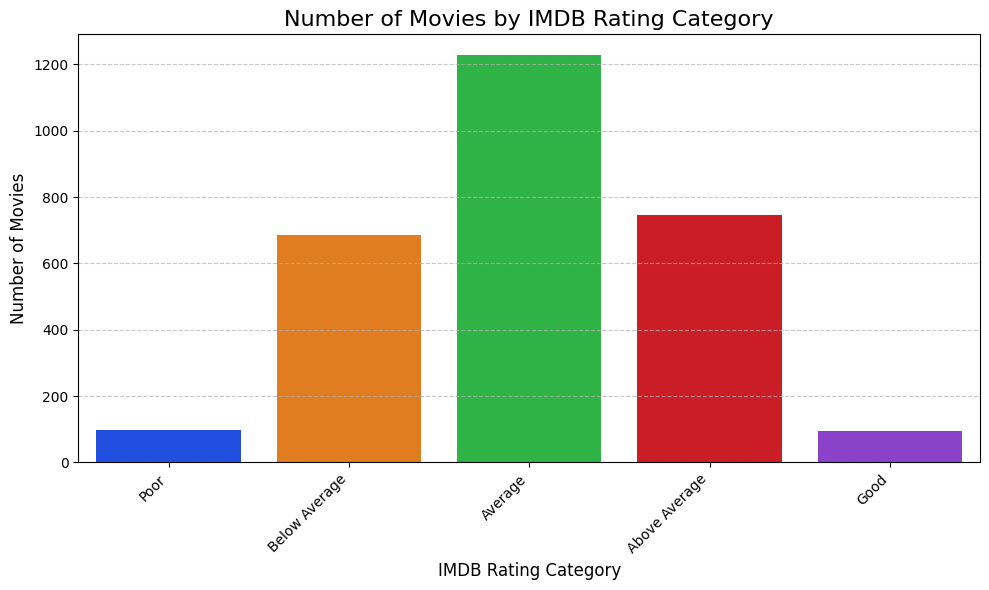

In [ ]:
rating_cat_counts = movies_df['rating_category'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_cat_counts.index, y=rating_cat_counts.values, palette=sns.color_palette(palette='bright', n_colors=5))
plt.title('Number of Movies by IMDB Rating Category', fontsize=16)
plt.xlabel('IMDB Rating Category', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

To observe the frequency of different rating categories for each production budget, international box office and domestic box office categories heatmap plots are considered.

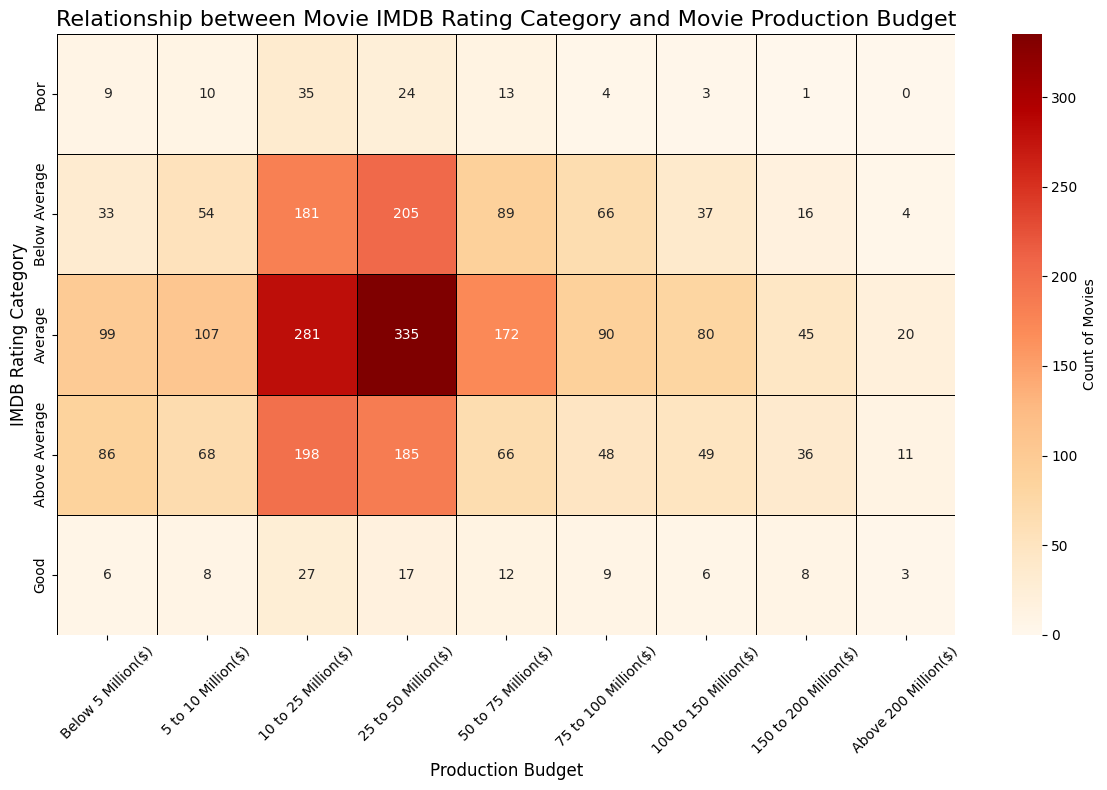

In [16]:
contingency_table = pd.crosstab(
    movies_df['rating_category'],
    movies_df['production_budget_category']
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    contingency_table,
    annot=True,
    fmt='d',
    cmap='OrRd',
    linecolor='Black',
    linewidths=.5,
    cbar_kws={'label': 'Count of Movies'}
)

plt.title('Relationship between Movie IMDB Rating Category and Movie Production Budget', fontsize=16)
plt.ylabel('IMDB Rating Category', fontsize=12)
plt.xlabel('Production Budget', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

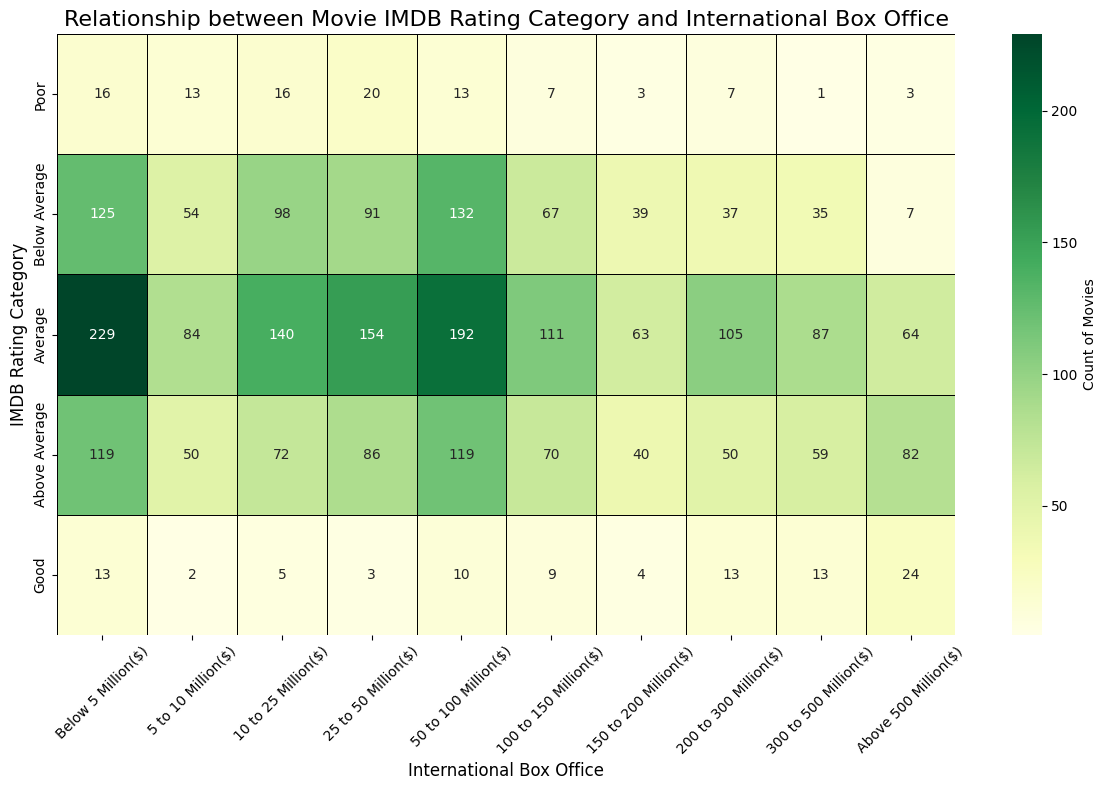

In [17]:
contingency_table = pd.crosstab(
    movies_df['rating_category'],
    movies_df['IBO_category']
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    contingency_table,
    annot=True,
    fmt='d',
    cmap='YlGn',
    linecolor='Black',
    linewidths=.5,
    cbar_kws={'label': 'Count of Movies'}
)

plt.title('Relationship between Movie IMDB Rating Category and International Box Office', fontsize=16)
plt.ylabel('IMDB Rating Category', fontsize=12)
plt.xlabel('International Box Office', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

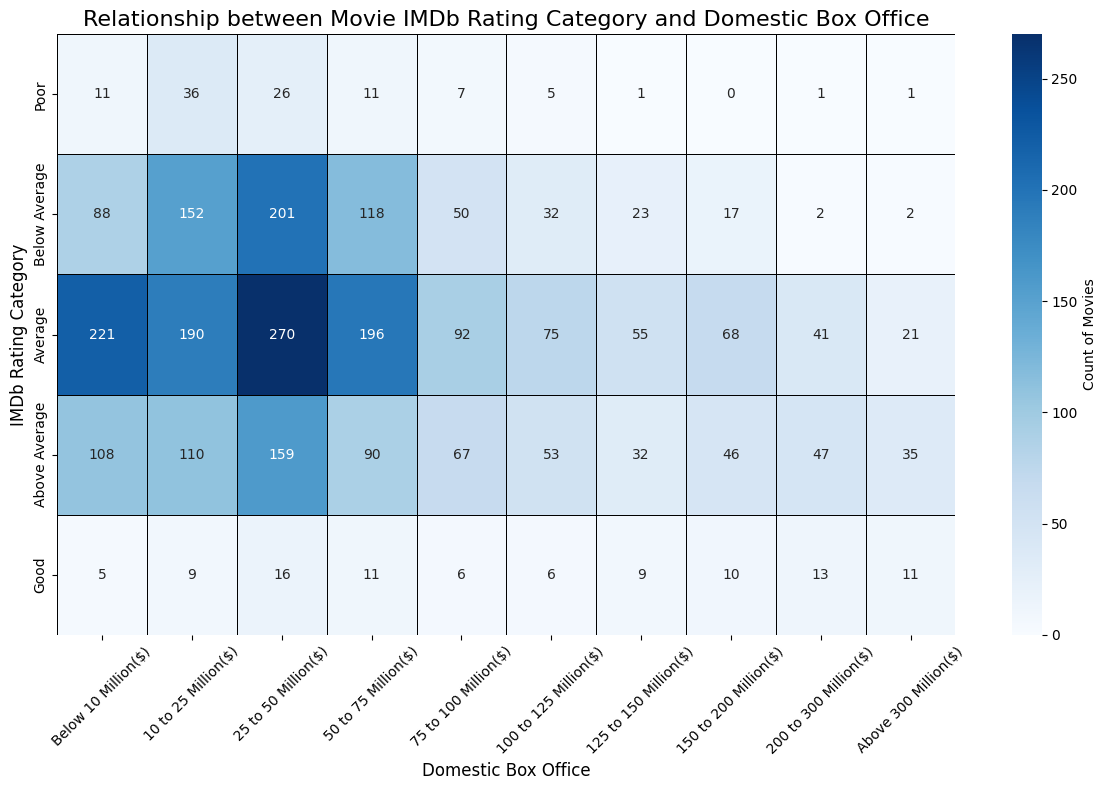

In [18]:
contingency_table = pd.crosstab(
    movies_df['rating_category'],
    movies_df['DBO_category']
)

plt.figure(figsize=(12, 8))
sns.heatmap(
    contingency_table,
    annot=True,
    fmt='d',
    cmap='Blues',
    linecolor='Black',
    linewidths=.5,
    cbar_kws={'label': 'Count of Movies'}
)

plt.title('Relationship between Movie IMDb Rating Category and Domestic Box Office', fontsize=16)
plt.ylabel('IMDb Rating Category', fontsize=12)
plt.xlabel('Domestic Box Office', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Computing the correlation coefficient among the International Box Office, Domestic Box Office or Production budget of the movie with its IMDB score, we can observe a weak positive relationship among the pair of variables. However there can be observed a slightly evident relationship among the correlations of production budget and IBO and DBO values so that a movie having a higher budget is more probable to have a better Box Office sale which is understandable as there might be more budget for advertisments dedicated when there is a higher production budget.

In [19]:
print("--- Correlation: Budget vs DBO vs IBO vs rating ---")
print(movies_df[["production_budget", "DBO", "IBO", "rating"]].corr())

--- Correlation: Budget vs DBO vs IBO vs rating ---
                   production_budget       DBO       IBO    rating
production_budget           1.000000  0.650123  0.665753  0.054883
DBO                         0.650123  1.000000  0.850731  0.255468
IBO                         0.665753  0.850731  1.000000  0.230678
rating                      0.054883  0.255468  0.230678  1.000000


The bar plot demonstrates a higher frequency of movies released after the year 2000 compared to earlier periods, which is likely due to incomplete data for older films.

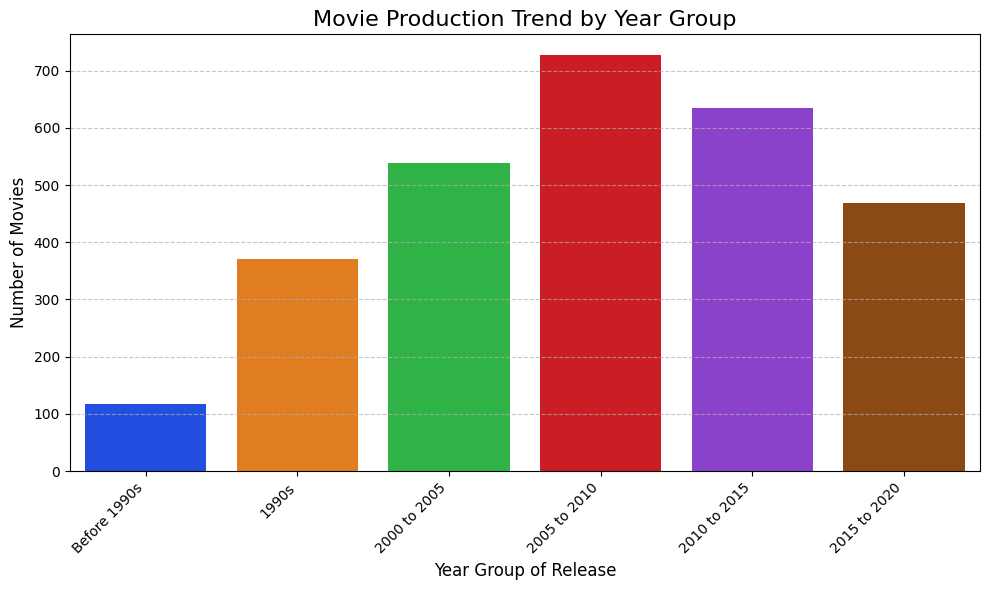

In [20]:
year_counts = movies_df['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=year_counts.index, y=year_counts.values, palette=sns.color_palette(palette='bright', n_colors=6))
plt.title('Movie Production Trend by Year Group', fontsize=16)
plt.xlabel('Year Group of Release', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

Observing the grouped barplot and stacked barplot we can understand that the movies with longer runtime are tend to have better ratings and vice versa. However in the groupped barplot we can see a very close to normal distribution bar plots for movies having an average runtime.

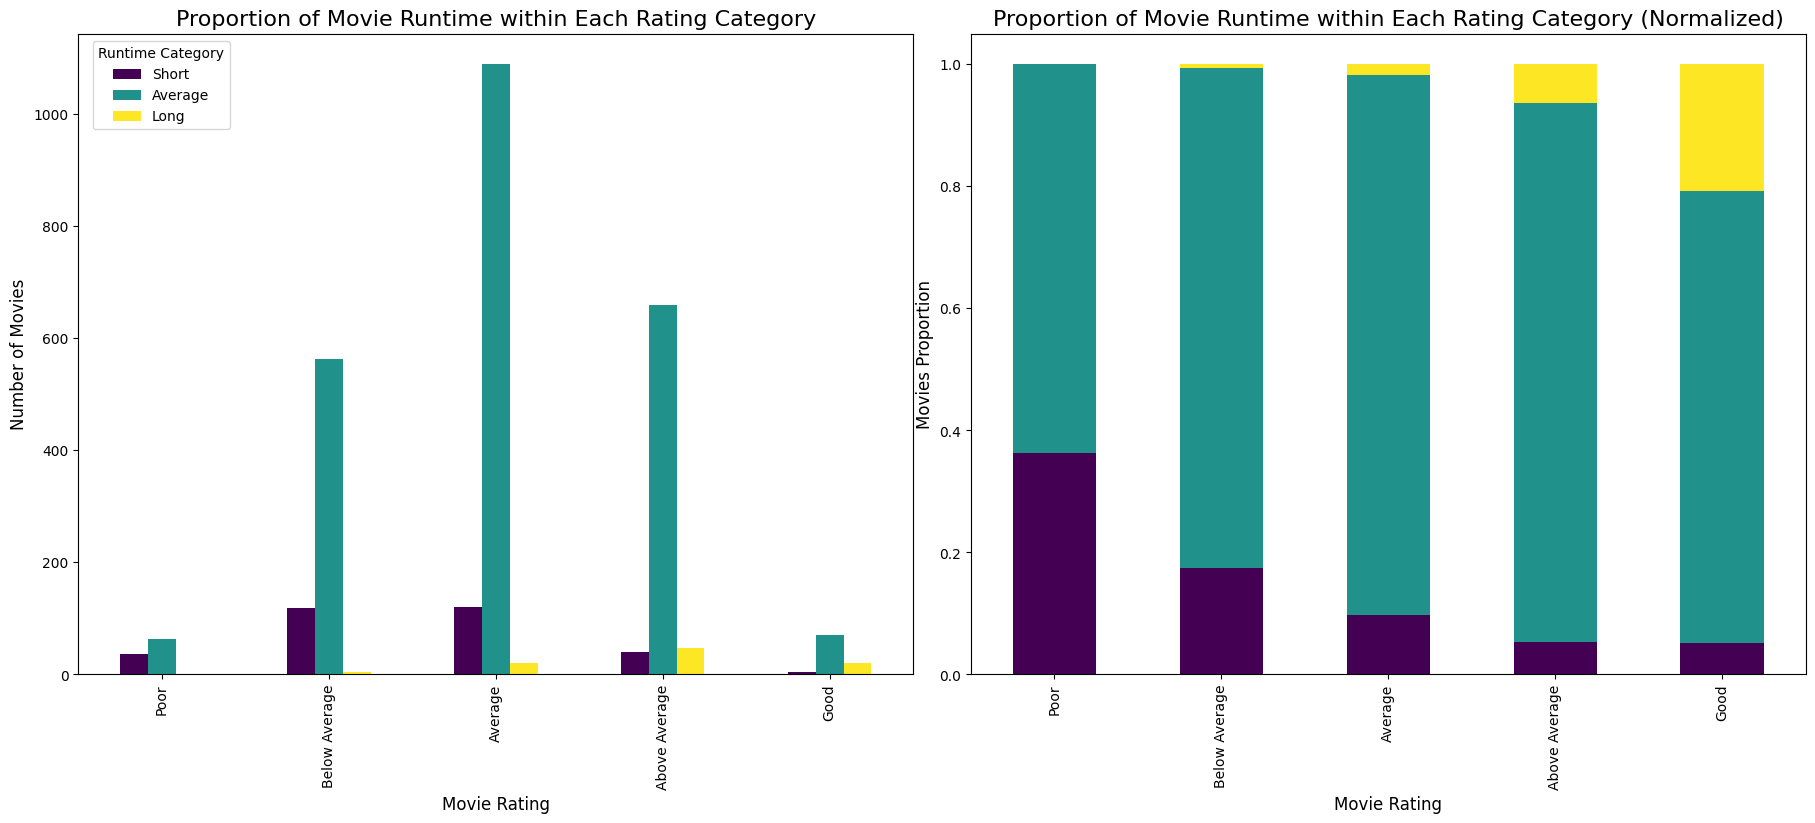

In [21]:
# Creating the Contingency Tables (Raw and Normalized) for grouped barplot and stacked barplot
contingency_table_rating_runtime = pd.crosstab(
    movies_df['rating_category'], 
    movies_df['runtime_category']
)

contingency_table_rating_runtime_normalized = pd.crosstab(
    movies_df['rating_category'], 
    movies_df['runtime_category'],
    normalize='index'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.tight_layout()
axes = axes.flatten()

contingency_table_rating_runtime.plot(
    kind='bar', 
    ax=axes[0],
    colormap='viridis'
)

contingency_table_rating_runtime_normalized.plot(
    kind='bar', 
    stacked=True, 
    ax=axes[1],
    colormap='viridis'
)

axes[0].set_title('Proportion of Movie Runtime within Each Rating Category', fontsize=16)
axes[0].set_xlabel('Movie Rating', fontsize=12)
axes[0].set_ylabel('Number of Movies', fontsize=12)

axes[1].set_title('Proportion of Movie Runtime within Each Rating Category (Normalized)', fontsize=16)
axes[1].set_xlabel('Movie Rating', fontsize=12)
axes[1].set_ylabel('Movies Proportion', fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend_.remove()
axes[1].legend_.remove()

fig.legend(
    handles, 
    labels, 
    title='Runtime Category', 
    loc='upper left',
    bbox_to_anchor=(0.03, 0.97),
)

plt.show()

In [22]:
movies_df.drop(columns=['genre', 'rating', 'runtime', 'production_budget', 'DBO', 'IBO'], axis=1, inplace=True)
movies_df.rename(columns={'runtime_category': 'runtime', 'IBO_category': 'IBO',
                          'DBO_category': 'DBO', 'rating_category': 'rating',
                          'production_budget_category': 'production_budget'}, inplace=True)
movies_df.to_csv("Movies_dataset.csv", index=False)